In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import bpmeth
import sympy as sp

Define multipole coefficients in a curved frame, then build $\vec{A}$, H and track.

curvature h[m^-1]:  1 radius of curvature [m]:  1.0
E [GeV]:  1.03827208816
beta0:  0.42819548497881543


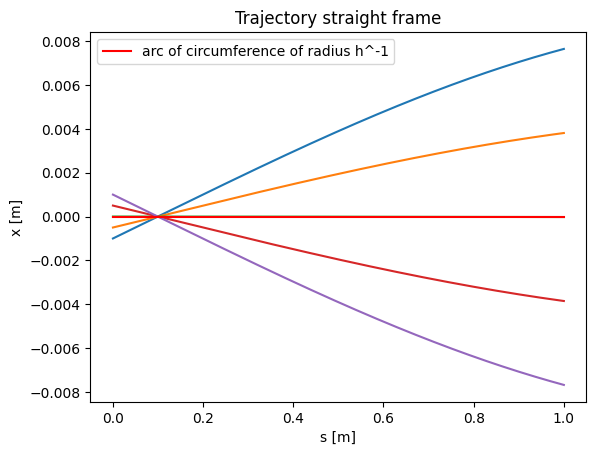

In [3]:
a_curved = [0,]
b_curved = [1,0.2]
h= b_curved[0]# considering normalization B/Brho=1/rho=h
print("curvature h[m^-1]: ", h, "radius of curvature [m]: ", 1/h)
#I want to track protons of given kinetic energy
Ek=1e8 #eV
p=np.sqrt(Ek**2+2*Ek*xt.PROTON_MASS_EV)#momentum eV/c
Eref = Ek + xt.PROTON_MASS_EV
print("E [GeV]: ", Eref/1e9)
gamma0 = Eref/xt.PROTON_MASS_EV
beta0 = np.sqrt(1-1/gamma0**2)
print("beta0: ", beta0)
p0 =xt.Particles(x=np.linspace(-1e-3, 1e-3, 5), y=0, s=0,py=0.01, px=np.linspace(0.01,-0.01,5), ptau=0, beta0=beta0, energy0=Eref, mass0=xt.PROTON_MASS_EV)
p_1 = p0.copy()

A_curved= bpmeth.GeneralVectorPotential(h=h, b=b_curved, a=a_curved)
H_curved = bpmeth.Hamiltonian(length=1, h=h, vectp=A_curved)

sol_curved = H_curved.track(p_1, return_sol=True, ivp_opt= {"rtol":1e-10, "atol":1e-12})

for ss in sol_curved:
    plt.plot(ss.t, ss.y[0])
plt.xlabel('s [m]')
plt.ylabel('x [m]')
plt.title("Trajectory straight frame")
x=np.linspace(0,1,50)
y= np.zeros_like(x)
plt.plot(x,y, color='red', label='arc of circumference of radius h^-1')
plt.legend()
plt.show()

Then work at the level of the scalar potential because being a scalar is invariant under change of frame (only the coordinates change). Because of this we can move to the straight frame and perform a harmonic analysis, chacking how the a,b coefficients look in that frame.

In [4]:
expansion_curved = bpmeth.FieldExpansion(a=a_curved, b=b_curved, h=h, nphi=7)
phi_curved = expansion_curved.get_phi()
print("phi curved frame: ", phi_curved)
#transform the scalar potential to curved frame using coordinate transformations
#xcurved =sqrt((x+rho)**2+s**2)-rho       scurved=rho*arctan(s/(x+rho))   with rho=1/h
x, y, s = sp.symbols('x y s', real=True)
xtmp, stmp = sp.symbols("xtmp stmp", real=True)
# rename the curved coordinates temporarily
phi_tmp = phi_curved.xreplace({
    x: xtmp,
    s: stmp
})
# substitute curved -> straight
phi_straight = phi_tmp.xreplace({
    xtmp: sp.sqrt((x + 1/h)**2 + s**2) - 1/h,
    stmp: 1/h * sp.atan(s/(x + 1/h))
})
print("\nphi straight frame: ", phi_straight)

Bxstraight_ana = -phi_straight.diff(x)
Bystraight_ana = -phi_straight.diff(y)
Bsstraight_ana = -phi_straight.diff(s)
print("\nBx straight frame: ", Bxstraight_ana)

phi curved frame:  y**5*(0.2*x + 0.2)/(120*(1.0*x**4 + 4.0*x**3 + 6.0*x**2 + 4.0*x + 1.0)) - y**3*(0.2*x + 0.2)/(6*(1.0*x + 1)**2) + y*(0.2*x + 1)

phi straight frame:  0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0) - 0.0333333333333333*y**3/sqrt(s**2 + (x + 1.0)**2) + y*(0.2*sqrt(s**2 + (x + 1.0)**2) + 0.8)

Bx straight frame:  -0.00166666666666667*y**5*sqrt(s**2 + (x + 1.0)**2)*(-4.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2/sqrt(s**2 + (x + 1.0)**2) - 12.0*(x + 1.0)*(sqrt(s**2 + (x + 1.0)**2) - 1.0)/sqrt(s**2 + (x + 1.0)**2) - 4.0*(x + 1.0)/sqrt(s**2 + (x + 1.0)**2))/(4.0*sqrt(s**2 + (x + 1.0)**2) + 1.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**4 + 4.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**3 + 6.0*(sqrt(s**2 + (x + 1.0)**2) - 1.0)**2 - 3.0)*

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:94: UserWarning: More terms are needed in the expansion for aperture 0.05m, the laplacian is 3.67277890739315E-9
  warnings.warn(f"More terms are needed in the expansion for aperture {apperture}m, the laplacian is {laplval}")


In [ ]:
#evaluate fields on grid 
xstraightarray = np.linspace(-1,1,100)
ystraightarray = np.linspace(-1,1,100)
ns=40
sstraightarray = np.linspace(0,1,ns)
Xstraight, Ystraight, Sstraight = np.meshgrid(xstraightarray, ystraightarray, sstraightarray, indexing='ij')
Bxstraight_ana_array = sp.lambdify((x,y,s), Bxstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight)
Bystraight_ana_array = sp.lambdify((x,y,s), Bystraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight)
Bsstraight_ana_array = sp.lambdify((x,y,s), Bsstraight_ana, 'numpy')(Xstraight, Ystraight, Sstraight)
#make a fieldmap object from the field arrays
datastraightfm = np.column_stack((Xstraight.flatten(), Ystraight.flatten(), Sstraight.flatten(), Bxstraight_ana_array.flatten(), Bystraight_ana_array.flatten(), Bsstraight_ana_array.flatten()))
fm_straight = fm = bpmeth.fieldmaps.Fieldmap(datastraightfm)
#before making the HA sample the field on a cylindrical grid
ntheta=128
nr=40
def interp_cartesian_to_cylindrical(cart_fieldmap, x_1d, y_1d, s_1d,
                                        rmin=0.001, rmax=0.4, nr=128,
                                        ntheta=256, ns=40, nk=4, nl=3):
    """
    Convert Cartesian fieldmap to cylindrical 
    Parameters
    ----------
    cart_fieldmap : ndarray, shape (N, 6)
        Fieldmap in Cartesian: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays from Cartesian grid
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    
    Returns
    -------
    fields: list
        list containing Bx, By, Bs
    rr : ndarray
        Radial coordinate array
    s_cyl : ndarray
        Cylindrical s coordinate array
    """
    # Resample Cartesian data onto cylindrical grid
    rr = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl = s_1d
    
    R, TH, S = np.meshgrid(rr, theta_1d, s_cyl, indexing='ij')
    
    # Convert to Cartesian for interpolation
    X_query = R * np.cos(TH)
    Y_query = R * np.sin(TH)
    
    # Reshape for interpolation
    shape_src = (len(x_1d), len(y_1d), len(s_1d))
    query_pts = np.column_stack([
        X_query.ravel(),
        Y_query.ravel(),
        S.ravel(),
    ])
    
    # Interpolate field components
    from scipy.interpolate import RegularGridInterpolator
    
    fields = {}
    for i, name in enumerate(['Bx', 'By', 'Bs']):
        F_3d = cart_fieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(nr, ntheta, ns)
    
    return rr, s_cyl, fields

# Construct By + i*Bx on cylindrical grid
ByiBx_cyl = fields['By'] + 1j * fields['Bx']